In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import seaborn as sns

# Step 1: Loading the data
# Load the CSV file containing the email data into a pandas DataFrame.
data = pd.read_csv('spam mail.csv')

# Displaying the loaded data to understand its structure
print(data)



     Category                                           Masseges
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham              Will Ì_ b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [36]:
# Step 2: Handling null values (data cleaning)
# Replace any NaN values in the dataset with empty strings to avoid errors in text processing.
mail = data.where((pd.notnull(data)), '')
# Displaying the first 5 rows of the data to verify the cleaning step
data.head(5)



,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [37]:
# Step 3: Converting 'spam' to 0 and 'ham' to 1 for the 'Category' column
# This step converts the categorical labels into numerical labels for model compatibility.
mail.loc[mail['Category'] == 'spam', 'Category'] = 0
mail.loc[mail['Category'] == 'ham', 'Category'] = 1



In [38]:
# Step 4: Separating data into texts (X) and labels (Y)
# Separate the messages (X) from the categories (Y) for feature extraction and model training.
X = mail['Masseges']
Y = mail['Category']

# Displaying the messages and corresponding categories to ensure proper separation
print(X)
print(Y)



0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Masseges, Length: 5572, dtype: object
0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: object


In [39]:
# Step 5: Splitting the data into training and testing sets
# Split the data into training and testing sets (80% training, 20% testing) to evaluate model performance.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=22)

# Displaying the shapes of the data subsets to verify the split
print(X.shape)
print(X_test.shape)
print(X_train.shape)



(5572,)
(1115,)
(4457,)


In [40]:
# Step 6: Transforming texts into numerical features using TF-IDF Vectorizer
# Convert the text data into numerical features using TF-IDF to represent the importance of words.
feature_extraction = TfidfVectorizer(lowercase=True)
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)



In [41]:
# Step 7: Converting Y_train and Y_test to integers
# Convert the label data to integers for compatibility with the logistic regression model.
Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

# Displaying the transformed training texts and their features to verify the transformation
print(X_train)
print(X_train_features)




813                                   I borrow ur bag ok.
801     Appt is at &lt;TIME&gt; am. Not my fault u don...
1994               Have you been practising your curtsey?
4227                             Have you started in skye
1672    URGENT! We are trying to contact U. Todays dra...
                              ...                        
4587    I wanted to wish you a Happy New Year and I wa...
5478                            No probably  &lt;#&gt; %.
356     Congratulations ur awarded 500 of CD vouchers ...
4908                             Will do. Have a good day
2933      Yup n her fren lor. I'm meeting my fren at 730.
Name: Masseges, Length: 4457, dtype: object
  (0, 1432)	0.6604786083566566
  (0, 7110)	0.30965030549789446
  (0, 1198)	0.6053464396990214
  (0, 4860)	0.31849707086884466
  (1, 1035)	0.38806813551137265
  (1, 3694)	0.1488427692777084
  (1, 1111)	0.18254962808510442
  (1, 4191)	0.2087968852918351
  (1, 6817)	0.2098974141104841
  (1, 3215)	0.20906974571274112
  (

In [42]:
# Step 8: Training the logistic regression model
# Train the logistic regression model using the transformed training data.
model = LogisticRegression()
model.fit(X_train_features, Y_train)



LogisticRegression()

In [43]:
# Step 9: Making predictions on training data and calculating accuracy
# Predict the labels for the training data and calculate the accuracy to evaluate model performance.
prediction_data = model.predict(X_train_features)
accuracy = accuracy_score(Y_train, prediction_data)
print('Accuracy on training data:', accuracy)



Accuracy on training data: 0.9739735247924612


In [44]:
# Step 10: Making predictions on testing data and calculating accuracy
# Predict the labels for the testing data and calculate the accuracy to evaluate model performance.
prediction_data2 = model.predict(X_test_features)
accuracy2 = accuracy_score(Y_test, prediction_data2)
print('Accuracy on testing data:', accuracy2)



Accuracy on testing data: 0.967713004484305


Precision: 0.9661016949152542
Recall: 0.9979402677651905
F1-Score: 0.9817629179331308
ROC-AUC Score: 0.8809145783270396


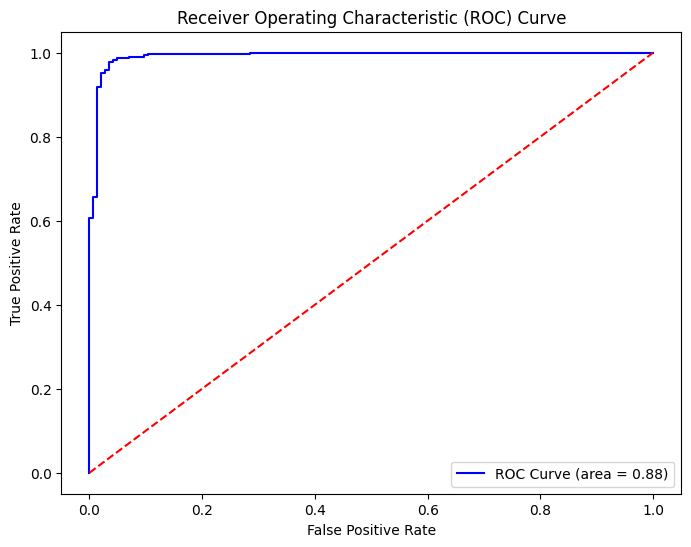

In [45]:
# Step 11: Additional Metrics Calculation
# Calculate precision, recall, F1-score, and ROC-AUC score to provide a more comprehensive evaluation of the model.
precision = precision_score(Y_test, prediction_data2)
recall = recall_score(Y_test, prediction_data2)
f1 = f1_score(Y_test, prediction_data2)
print('Precision:', precision)
print('Recall:', recall)
print('F1-Score:', f1)

# Calculate ROC-AUC score to evaluate the model's ability to distinguish between classes.
roc_auc = roc_auc_score(Y_test, prediction_data2)
print('ROC-AUC Score:', roc_auc)

# Plot ROC Curve to visualize the trade-off between the true positive rate and false positive rate.
fpr, tpr, thresholds = roc_curve(Y_test, model.predict_proba(X_test_features)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()



In [46]:
# Step 12: User input prediction
# Allow user to input a message and predict whether it's spam or ham.
user_input = input("Please enter your text: ")
inbox = [user_input]
in_data_features = feature_extraction.transform(inbox)
pred = model.predict(in_data_features)


# Displaying whether the prediction is spam or ham
if pred[0] == 1:
    print('It is a ham email')
else:
    print('It is a spam email')



It is a spam email


(0.0, 1.0)

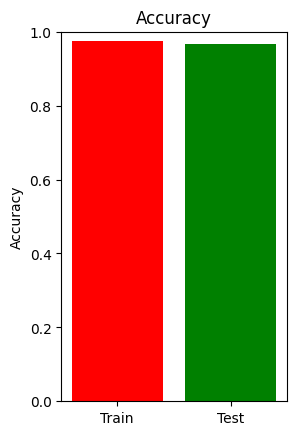

In [47]:
# Step 13: Visualization

# Step 13.1: Accuracy bar plot
# Plot a bar chart to compare the accuracy on training and testing data.
plt.subplot(1, 2, 1)
labels = ['Train', 'Test']
accuracies = [accuracy, accuracy2]
plt.bar(labels, accuracies, color=['red', 'green'])
plt.title('Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)



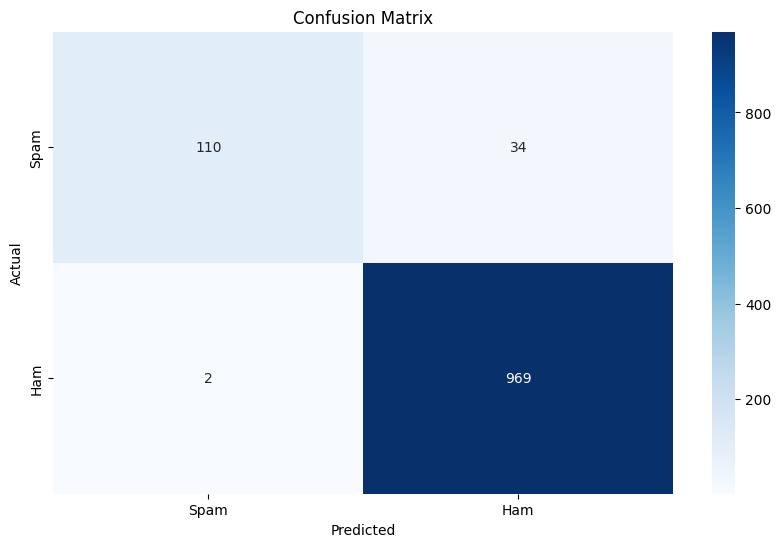

In [48]:
# Step 13.2: Confusion Matrix
# Create and plot a confusion matrix to visualize the model's performance in terms of true/false positives and negatives.
conf_matrix = confusion_matrix(Y_test, prediction_data2)
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



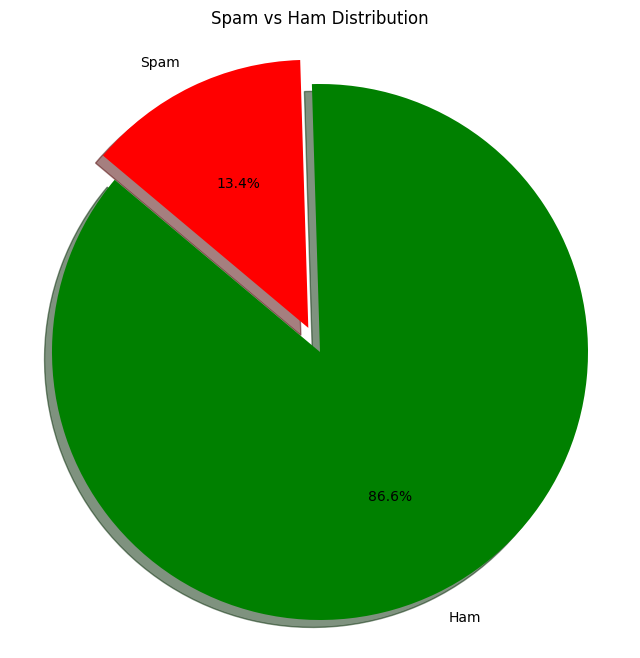

In [49]:
# Step 13.3: Pie chart for spam vs ham distribution
# Plot a pie chart to visualize the distribution of spam vs ham emails in the dataset.
category_counts = mail['Category'].value_counts()
labels = ['Ham', 'Spam']
sizes = [category_counts[1], category_counts[0]]
colors = ['green', 'red']
explode = (0.1, 0)  # Explode the first slice (Ham)
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Spam vs Ham Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Top 10 words used in spam emails:
        term     weight
6848      to  50.813121
1593    call  41.973013
2945    free  31.459094
7620    your  29.625024
7614     you  25.070464
7006     txt  23.443056
4784     now  23.170204
4918      or  22.643530
2903     for  22.057190
4486  mobile  20.271016
1805   claim  19.237286
6735     the  18.534574
6707    text  18.425028
6423    stop  18.296931
2983    from  18.213699
3310    have  17.753796
7110      ur  17.580941
5361   prize  17.301948
4880      on  16.538277
3694      is  16.497373
5647   reply  16.478394
7549     www  16.075543
4948     our  13.954719
1662    cash  13.669058
7455    with  13.648225


C:\Users\hp\AppData\Local\Temp\ipykernel_15316\465866379.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weight', y='term', data=top_terms, palette='viridis')


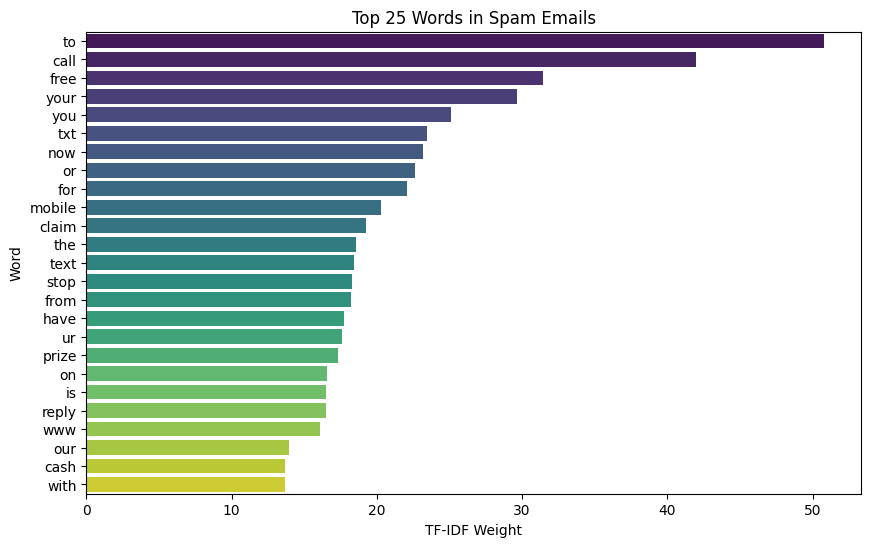

In [57]:
# Step 14: Extracting top 10 words used in spam emails
# Filter the dataset to include only spam emails
spam_emails = mail[mail['Category'] == 0]

# Transform spam email texts using TF-IDF Vectorizer to get term weights
spam_features = feature_extraction.transform(spam_emails['Masseges'])

# Sum the TF-IDF weights for each term in the spam emails
spam_term_weights = np.sum(spam_features, axis=0).A1

# Get the feature names (words) from the TF-IDF Vectorizer
terms = feature_extraction.get_feature_names_out()

# Create a DataFrame with terms and their corresponding weights
term_weights_df = pd.DataFrame({'term': terms, 'weight': spam_term_weights})

# Sort the DataFrame by weight in descending order to get the top terms
top_terms = term_weights_df.sort_values(by='weight', ascending=False).head(25)

# Display the top 10 terms used in spam emails
print('Top 10 words used in spam emails:')
print(top_terms)

# Visualize the top 10 spam words with a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='weight', y='term', data=top_terms, palette='viridis')
plt.title('Top 25 Words in Spam Emails')
plt.xlabel('TF-IDF Weight')
plt.ylabel('Word')
plt.show()

Top 10 words used in ham emails:
      term      weight
7614   you  226.376221
6848    to  160.049687
6735   the  129.600230
3585    in  118.159377
4345    me  117.856661
4605    my  105.995173
959    and  104.071326
3704    it  101.938579
3694    is   95.320387
4860    ok   90.674285
6730  that   89.390602
1047   are   77.649250
1618   can   76.521711
2903   for   72.842611
3310  have   72.505293
4771   not   72.257115
6198    so   72.119684
4834    of   71.807689
2335    do   69.937102
1111    at   69.339660
1559   but   67.327659
4104    ll   67.174795
3466   how   65.849581
7425  will   65.814440
7620  your   64.999940


C:\Users\hp\AppData\Local\Temp\ipykernel_15316\389732604.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weight', y='term', data=top_ham_terms, palette='viridis')


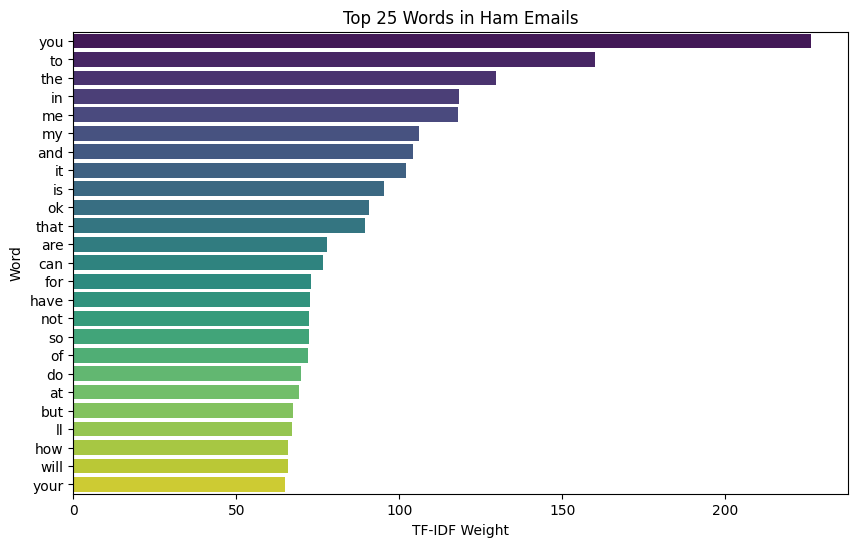

In [60]:
# Step 15: Extracting top 10 words used in ham emails
# Filter the dataset to include only ham emails
ham_emails = mail[mail['Category'] == 1]

# Transform ham email texts using TF-IDF Vectorizer to get term weights
ham_features = feature_extraction.transform(ham_emails['Masseges'])

# Sum the TF-IDF weights for each term in the ham emails
ham_term_weights = np.sum(ham_features, axis=0).A1

# Create a DataFrame with terms and their corresponding weights for ham emails
ham_term_weights_df = pd.DataFrame({'term': terms, 'weight': ham_term_weights})

# Sort the DataFrame by weight in descending order to get the top terms
top_ham_terms = ham_term_weights_df.sort_values(by='weight', ascending=False).head(25)

# Display the top 10 terms used in ham emails
print('Top 10 words used in ham emails:')
print(top_ham_terms)

# Visualize the top 10 ham words with a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='weight', y='term', data=top_ham_terms, palette='viridis')
plt.title('Top 25 Words in Ham Emails')
plt.xlabel('TF-IDF Weight')
plt.ylabel('Word')
plt.show()